In [2]:
pip install pandas numpy matplotlib.pyplot seaborn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
# ==========================================
# Load Dataset
# ==========================================

train_df = pd.read_csv(r"C:\Users\ELCOT\Desktop\airline-passenger-segmentation\data\train.csv")

test_df = pd.read_csv(r"C:\Users\ELCOT\Desktop\airline-passenger-segmentation\data\test.csv")

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (103904, 25)
Test Shape  : (25976, 25)


In [5]:
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
train_df.tail()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,2,3,2,2,2,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,4,4,2,4,5,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,3,4,1,5,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,5,1,1,1,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied
103903,103903,62567,Male,Loyal Customer,27,Business travel,Business,1723,1,3,3,3,1,1,1,1,1,1,4,4,3,1,0,0.0,neutral or dissatisfied


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [8]:
print("Rows :", train_df.shape[0])

print("Columns :", train_df.shape[1])

Rows : 103904
Columns : 25


In [9]:
train_df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [10]:
train_df.drop(
    columns=["Unnamed: 0", "id"],
    inplace=True,
    errors="ignore"
)

test_df.drop(
    columns=["Unnamed: 0", "id"],
    inplace=True,
    errors="ignore"
)

In [11]:
train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [12]:
train_df.dtypes

Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfacti

In [13]:
train_df.dtypes.value_counts()

int64      17
object      5
float64     1
Name: count, dtype: int64

In [14]:
missing_values = train_df.isnull().sum()

missing_values

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [15]:
missing_values[missing_values > 0]

Arrival Delay in Minutes    310
dtype: int64

In [16]:
missing_percentage = (
    train_df.isnull().mean()*100
).sort_values(ascending=False)

missing_percentage[missing_percentage>0]

Arrival Delay in Minutes    0.298352
dtype: float64

In [17]:
train_df.duplicated().sum()

np.int64(0)

In [18]:
train_df.drop_duplicates(inplace=True)

In [19]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358158,1.332991,0.0,2.0,4.0,4.0,5.0


In [20]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358158,1.332991,0.0,2.0,4.0,4.0,5.0


In [21]:
for column in train_df.select_dtypes(include="object"):

    print("="*50)

    print(column)

    print(train_df[column].value_counts())

    print()

Gender
Gender
Female    52727
Male      51177
Name: count, dtype: int64

Customer Type
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

Type of Travel
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

Class
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64



In [22]:
train_df["satisfaction"].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [23]:
(
train_df["satisfaction"]
.value_counts(normalize=True)*100
).round(2)

satisfaction
neutral or dissatisfied    56.67
satisfied                  43.33
Name: proportion, dtype: float64

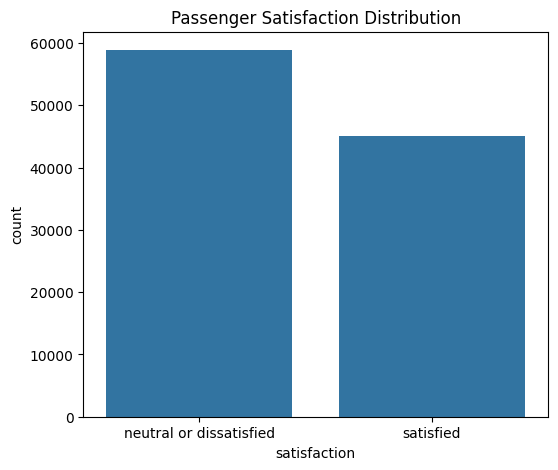

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train_df,
    x="satisfaction"
)

plt.title("Passenger Satisfaction Distribution")

plt.show()

In [25]:
categorical_columns = train_df.select_dtypes(
    include="object"
).columns.tolist()

numerical_columns = train_df.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical Features")

print(categorical_columns)

print()

print("Numerical Features")

print(numerical_columns)

Categorical Features
['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Numerical Features
['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [26]:
train_df["satisfaction"].value_counts(normalize=True)

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64

In [27]:
train_df.to_csv(
    "../data/train_clean.csv",
    index=False
)

test_df.to_csv(
    "../data/test_clean.csv",
    index=False
)

print("Clean datasets saved.")

Clean datasets saved.


In [28]:
summary = pd.DataFrame({

    "Feature": train_df.columns,

    "Data Type": train_df.dtypes.values,

    "Missing Values": train_df.isnull().sum().values,

    "Unique Values": train_df.nunique().values

})

summary

,Feature,Data Type,Missing Values,Unique Values
0,Gender,object,0,2
1,Customer Type,object,0,2
2,Age,int64,0,75
3,Type of Travel,object,0,2
4,Class,object,0,3
5,Flight Distance,int64,0,3802
6,Inflight wifi service,int64,0,6
7,Departure/Arrival time convenient,int64,0,6
8,Ease of Online booking,int64,0,6
9,Gate location,int64,0,6


In [29]:
summary.to_csv(
    r"C:\Users\ELCOT\Desktop\airline-passenger-segmentation\reports\dataset_summary.csv",
    index=False
)

summary.head()

,Feature,Data Type,Missing Values,Unique Values
0,Gender,object,0,2
1,Customer Type,object,0,2
2,Age,int64,0,75
3,Type of Travel,object,0,2
4,Class,object,0,3


In [30]:
train_df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [31]:
missing = train_df.isnull().sum()

missing[missing > 0]

Arrival Delay in Minutes    310
dtype: int64

In [32]:
train_df["Arrival Delay in Minutes"] = train_df[
    "Arrival Delay in Minutes"
].fillna(
    train_df["Arrival Delay in Minutes"].median()
)

test_df["Arrival Delay in Minutes"] = test_df[
    "Arrival Delay in Minutes"
].fillna(
    test_df["Arrival Delay in Minutes"].median()
)

In [33]:
train_df.isnull().sum().sum()

np.int64(0)

In [34]:
train_df.duplicated().sum()

np.int64(0)

In [35]:
train_df.drop_duplicates(inplace=True)

test_df.drop_duplicates(inplace=True)

In [36]:
numerical_columns = train_df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns.remove("satisfaction") if "satisfaction" in numerical_columns else None

print(numerical_columns)

['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [37]:
def cap_outliers(df, columns):

    df = df.copy()

    for col in columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower,
                           lower,
                           df[col])

        df[col] = np.where(df[col] > upper,
                           upper,
                           df[col])

    return df

In [38]:
train_df = cap_outliers(
    train_df,
    numerical_columns
)

test_df = cap_outliers(
    test_df,
    numerical_columns
)

In [39]:
train_df["satisfaction"] = train_df["satisfaction"].map({

    "satisfied":1,

    "neutral or dissatisfied":0

})

test_df["satisfaction"] = test_df["satisfaction"].map({

    "satisfied":1,

    "neutral or dissatisfied":0

})

In [40]:
train_df["satisfaction"].value_counts()

satisfaction
0    58879
1    45025
Name: count, dtype: int64

In [41]:
categorical_columns = train_df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')

In [42]:
# 1. Import the missing class
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in categorical_columns:
    # 2. Initialize and use the encoder
    encoder = LabelEncoder()
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.transform(test_df[col])
    
    # Optional: Save the encoder to your dictionary if you need it later
    encoders[col] = encoder


In [43]:
train_df.head()


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,4.0,3.0,4.0,4.0,5.0,5.0,25.0,18.0,0
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,1.0,5.0,3.0,1.5,4.0,1.0,1.0,6.0,0
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,4.0,3.0,4.0,4.0,4.0,5.0,0.0,0.0,1
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,2.0,5.0,3.0,1.5,4.0,2.0,11.0,9.0,0
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,0.0,0.0,1


In [44]:
train_df.head

<bound method NDFrame.head of         Gender  Customer Type   Age  Type of Travel  Class  Flight Distance  \
0            1              0  13.0               1      2            460.0   
1            1              1  25.0               0      0            235.0   
2            0              0  26.0               0      0           1142.0   
3            0              0  25.0               0      0            562.0   
4            1              0  61.0               0      0            214.0   
...        ...            ...   ...             ...    ...              ...   
103899       0              1  23.0               0      1            192.0   
103900       1              0  49.0               0      0           2347.0   
103901       1              1  30.0               0      0           1995.0   
103902       0              1  22.0               0      1           1000.0   
103903       1              0  27.0               0      0           1723.0   

        Inflight wifi

In [45]:
service_columns = [

    "Inflight wifi service",

    "Food and drink",

    "Online boarding",

    "Seat comfort",

    "Inflight entertainment",

    "On-board service",

    "Leg room service",

    "Baggage handling",

    "Checkin service",

    "Inflight service",

    "Cleanliness"

]

train_df["Overall_Service_Score"] = train_df[
    service_columns
].mean(axis=1)

test_df["Overall_Service_Score"] = test_df[
    service_columns
].mean(axis=1)

In [46]:
comfort_columns = [

    "Seat comfort",

    "Leg room service",

    "Cleanliness"

]

train_df["Comfort_Score"] = train_df[
    comfort_columns
].mean(axis=1)

test_df["Comfort_Score"] = test_df[
    comfort_columns
].mean(axis=1)

In [47]:
digital_columns = [

    "Inflight wifi service",

    "Ease of Online booking",

    "Online boarding"

]

train_df["Digital_Experience"] = train_df[
    digital_columns
].mean(axis=1)

test_df["Digital_Experience"] = test_df[
    digital_columns
].mean(axis=1)

In [48]:
train_df["Total_Delay"] = (

    train_df["Departure Delay in Minutes"]

    +

    train_df["Arrival Delay in Minutes"]

)

test_df["Total_Delay"] = (

    test_df["Departure Delay in Minutes"]

    +

    test_df["Arrival Delay in Minutes"]

)

In [49]:
train_df["Customer_Value"] = (

    train_df["Overall_Service_Score"] *

    train_df["Flight Distance"]

)

test_df["Customer_Value"] = (

    test_df["Overall_Service_Score"] *

    test_df["Flight Distance"]

)

In [50]:
experience_columns = [

    "Overall_Service_Score",

    "Comfort_Score",

    "Digital_Experience"

]

train_df["Travel_Experience"] = train_df[
    experience_columns
].mean(axis=1)

test_df["Travel_Experience"] = test_df[
    experience_columns
].mean(axis=1)

In [51]:
train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,4.0,3.0,4.0,4.0,5.0,5.0,25.0,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,1.0,5.0,3.0,1.5,4.0,1.0,1.0,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,4.0,3.0,4.0,4.0,4.0,5.0,0.0,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,2.0,5.0,3.0,1.5,4.0,2.0,11.0,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,0.0,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677


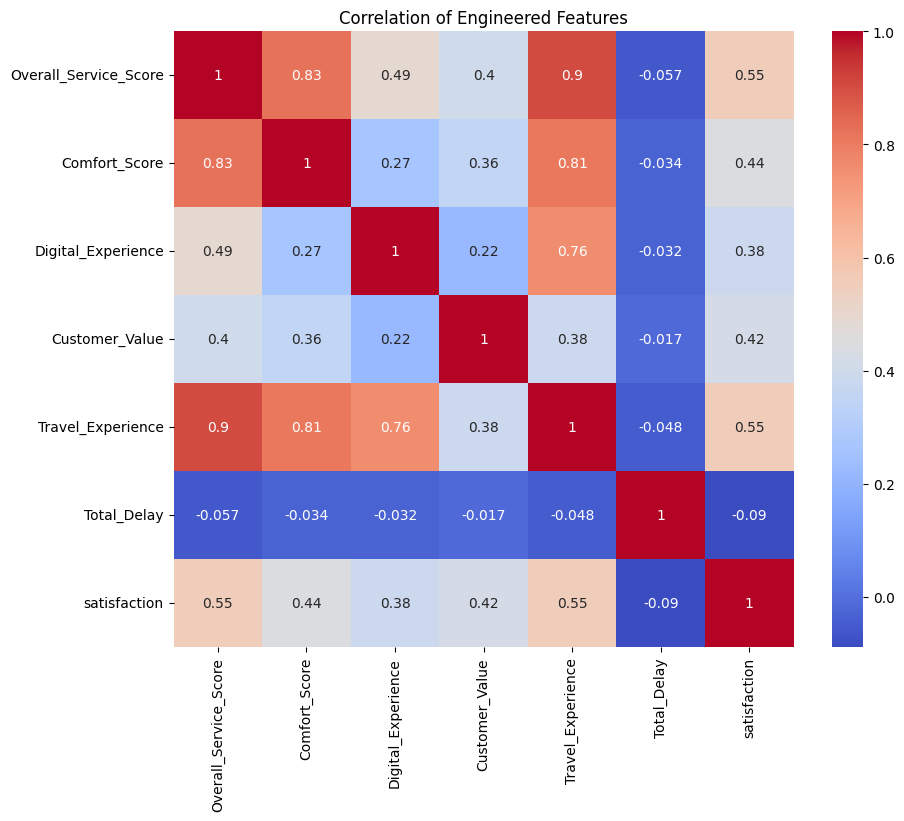

In [52]:
new_features = [

    "Overall_Service_Score",

    "Comfort_Score",

    "Digital_Experience",

    "Customer_Value",

    "Travel_Experience",

    "Total_Delay",

    "satisfaction"

]

plt.figure(figsize=(10,8))

sns.heatmap(

    train_df[new_features].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation of Engineered Features")

plt.show()

In [53]:
train_df.to_csv(

    "../data/train_processed.csv",

    index=False

)

test_df.to_csv(

    "../data/test_processed.csv",

    index=False

)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [54]:
import joblib

joblib.dump(

    encoders,

    "../models/label_encoders.pkl"

)

print("Label encoders saved.")

Label encoders saved.
